### Importing Libraries

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

### Load the dataset

In [50]:
data = pd.read_csv("hr_salary_data.csv")

### Feature Engineering

In [51]:
features = ["Age", "Years_of_Experience"]

X = data[features]
y = data["Target_Salary"]

### Train-test split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Train the models

In [53]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Train the model
linear_model.fit(X, y)

# Predict without using "Current Salary"
input_data = pd.DataFrame([[25, 5]], columns=["Age", "Years_of_Experience"])
prediction = linear_model.predict(input_data)

random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X, y)
prediction = ridge_model.predict(input_data)

### Evaluate Models

In [54]:
## Evaluate Models
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    return mse, mae, r2, predictions

# Linear Regression Metrics
mse_lr, mae_lr, r2_lr, preds_lr = evaluate_model(linear_model, X_test, y_test)
print(f"Linear Regression - MSE: {mse_lr}, MAE: {mae_lr}, R2: {r2_lr}")

# Random Forest Metrics
mse_rf, mae_rf, r2_rf, preds_rf = evaluate_model(random_forest_model, X_test, y_test)
print(f"Random Forest - MSE: {mse_rf}, MAE: {mae_rf}, R2: {r2_rf}")

Linear Regression - MSE: 24990754.04946001, MAE: 3975.5181655394294, R2: 0.5803292653618901
Random Forest - MSE: 25263988.718084224, MAE: 3997.3663925332785, R2: 0.5757408246176381


### Plotting for Linear Regression

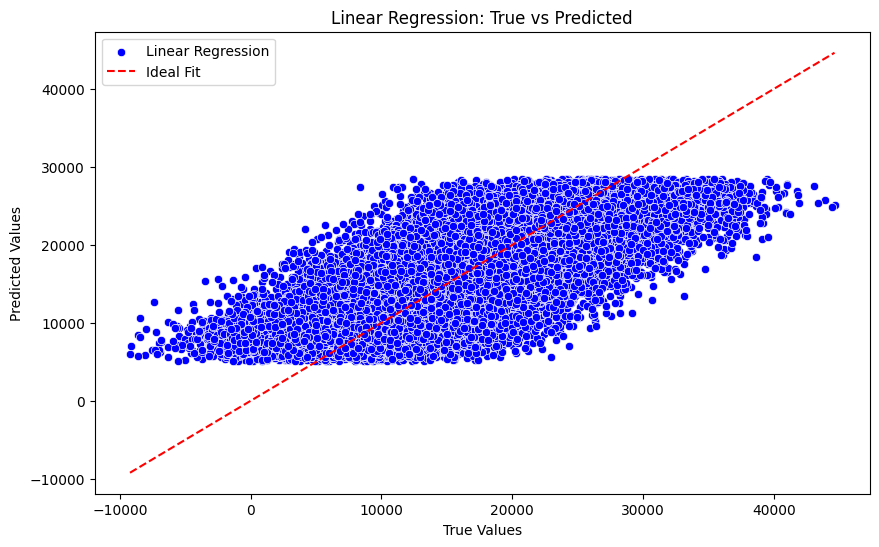

In [55]:
# Comparison of True vs Predicted for Linear Regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=preds_lr, label="Linear Regression", color="blue")
sns.lineplot(x=y_test, y=y_test, color="red", linestyle="--", label="Ideal Fit")
plt.title("Linear Regression: True vs Predicted")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()

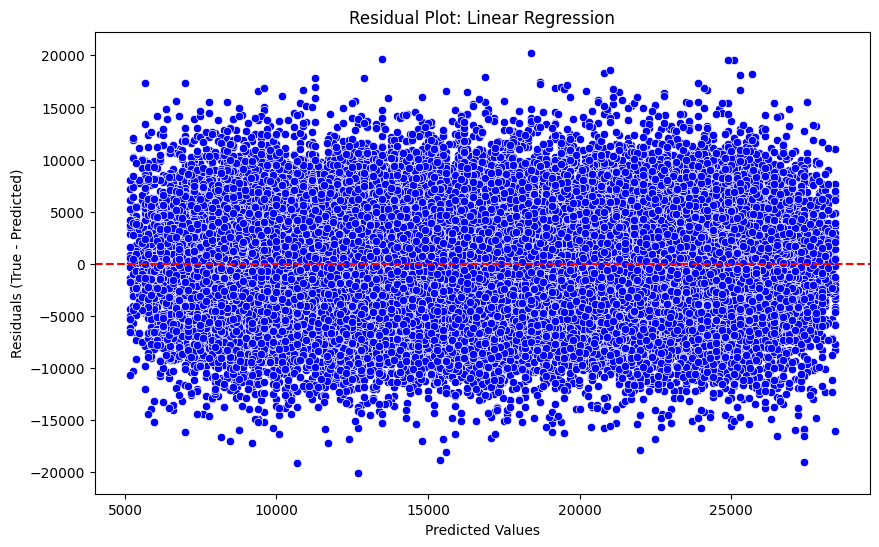

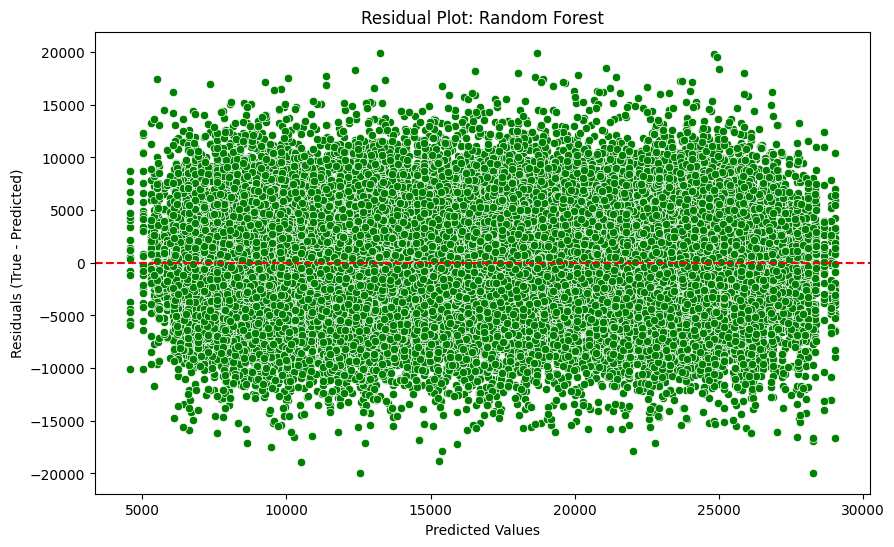

In [56]:
# Residual Plot for Linear Regression
residuals_lr = y_test - preds_lr

plt.figure(figsize=(10, 6))
sns.scatterplot(x=preds_lr, y=residuals_lr, color="blue")
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residual Plot: Linear Regression")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (True - Predicted)")
plt.show()

# Residual Plot for Random Forest
residuals_rf = y_test - preds_rf

plt.figure(figsize=(10, 6))
sns.scatterplot(x=preds_rf, y=residuals_rf, color="green")
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residual Plot: Random Forest")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (True - Predicted)")
plt.show()


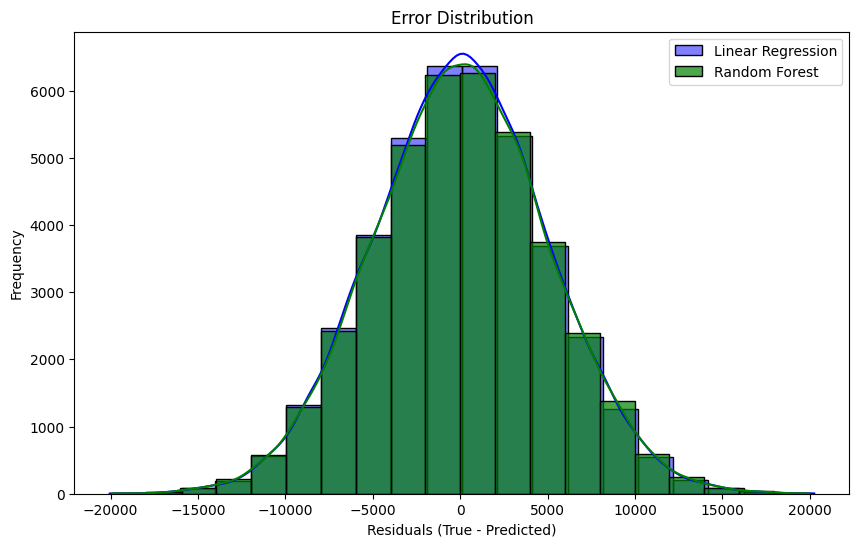

In [57]:
# Error Distribution Plot
plt.figure(figsize=(10, 6))
sns.histplot(residuals_lr, bins=20, kde=True, color="blue", label="Linear Regression")
sns.histplot(residuals_rf, bins=20, kde=True, color="green", label="Random Forest", alpha=0.7)
plt.title("Error Distribution")
plt.xlabel("Residuals (True - Predicted)")
plt.ylabel("Frequency")
plt.legend()
plt.show()


C:\Users\Shashank\AppData\Local\Temp\ipykernel_2164\1999681993.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=metrics_df, x="Model", y="MAE", palette=palette)
C:\Users\Shashank\AppData\Local\Temp\ipykernel_2164\1999681993.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=metrics_df, x="Model", y="R²", palette=palette)
C:\Users\Shashank\AppData\Local\Temp\ipykernel_2164\1999681993.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], data=metrics_df, x="Model", y="MSE", palette=palette)


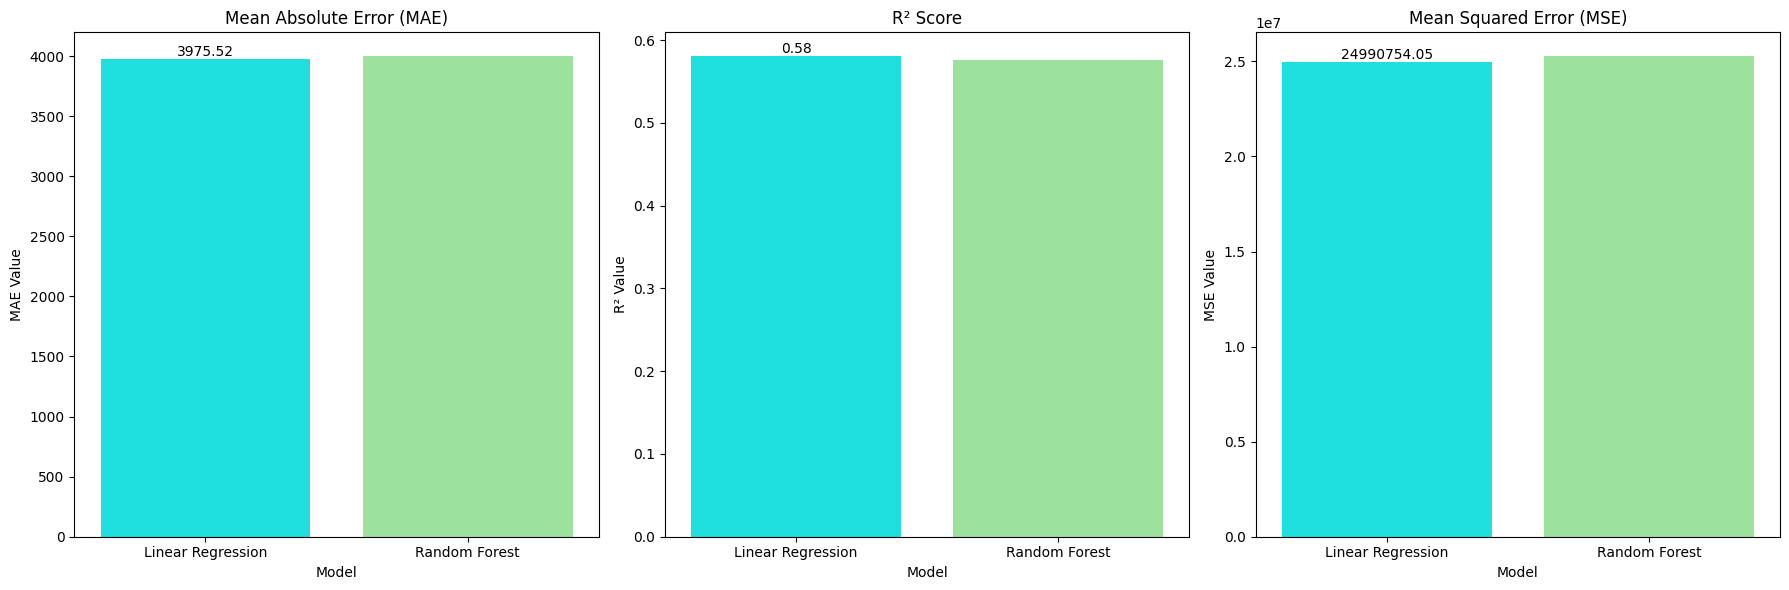

In [66]:
# Create DataFrame for Metrics
metrics_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "R²": [r2_lr, r2_rf],
    "MSE": [mse_lr, mse_rf]
})

# Define colors
palette = ["cyan", "lightgreen"]

# Plot Metrics in Subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

# Plot MAE
sns.barplot(ax=axes[0], data=metrics_df, x="Model", y="MAE", palette=palette)
axes[0].set_title("Mean Absolute Error (MAE)")
axes[0].set_ylabel("MAE Value")
axes[0].bar_label(axes[0].containers[0], fmt="%.2f")  # Annotate bars

# Plot R²
sns.barplot(ax=axes[1], data=metrics_df, x="Model", y="R²", palette=palette)
axes[1].set_title("R² Score")
axes[1].set_ylabel("R² Value")
axes[1].bar_label(axes[1].containers[0], fmt="%.2f")  # Annotate bars

# Plot MSE
sns.barplot(ax=axes[2], data=metrics_df, x="Model", y="MSE", palette=palette)
axes[2].set_title("Mean Squared Error (MSE)")
axes[2].set_ylabel("MSE Value")
axes[2].bar_label(axes[2].containers[0], fmt="%.2f")  # Annotate bars

# Final Adjustments
plt.tight_layout()
plt.show()


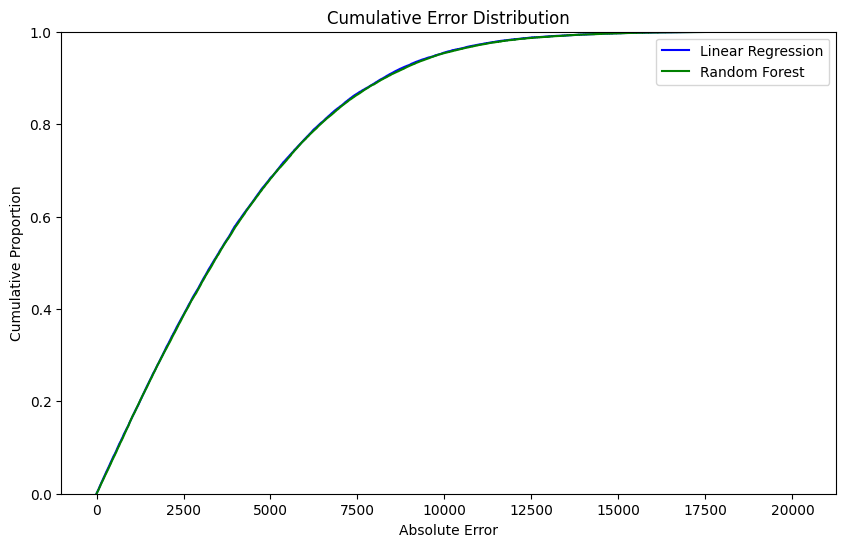

In [59]:
# Cumulative Error Distribution
errors_lr = abs(y_test - preds_lr)
errors_rf = abs(y_test - preds_rf)

plt.figure(figsize=(10, 6))
sns.ecdfplot(errors_lr, label="Linear Regression", color="blue")
sns.ecdfplot(errors_rf, label="Random Forest", color="green")
plt.title("Cumulative Error Distribution")
plt.xlabel("Absolute Error")
plt.ylabel("Cumulative Proportion")
plt.legend()
plt.show()


C:\Users\Shashank\AppData\Local\Temp\ipykernel_2164\3888948791.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Linear Regression", "Random Forest"], y=[r2_lr, r2_rf], palette=["cyan", "lightgreen"])


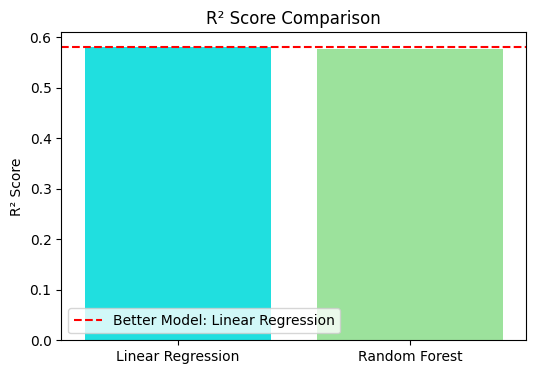

In [67]:
# Highlight Better Model
better_model = "Random Forest" if r2_rf > r2_lr else "Linear Regression"

plt.figure(figsize=(6, 4))
sns.barplot(x=["Linear Regression", "Random Forest"], y=[r2_lr, r2_rf], palette=["cyan", "lightgreen"])
plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.axhline(max(r2_lr, r2_rf), color="red", linestyle="--", label=f"Better Model: {better_model}")
plt.legend()
plt.show()


### Plotting for Random Forest 

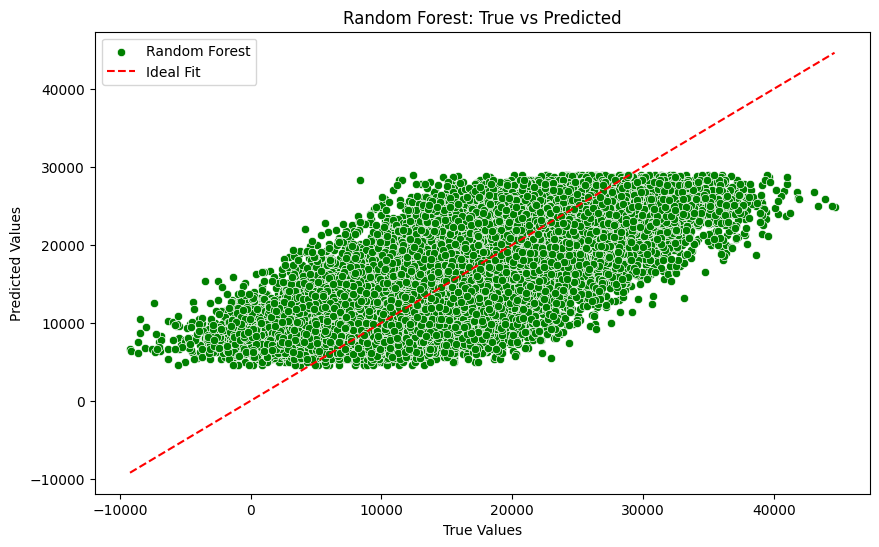

In [61]:
# Comparison of True vs Predicted for Random Forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=preds_rf, label="Random Forest", color="green")
sns.lineplot(x=y_test, y=y_test, color="red", linestyle="--", label="Ideal Fit")
plt.title("Random Forest: True vs Predicted")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()

### Save the better model 

In [62]:
## Save the better model
if r2_rf > r2_lr:
    joblib.dump(random_forest_model, "salary_predictor_model.pkl")
    print("Random Forest model saved as salary_predictor_model.pkl!")
else:
    joblib.dump(linear_model, "salary_predictor_model.pkl")
    print("Linear Regression model saved as salary_predictor_model.pkl!")

Linear Regression model saved as salary_predictor_model.pkl!
